In [1]:
import jax
import numpy as np
import pyamg
# jax.config.update('jax_enable_x64', True)

In [2]:
from sparse_solver import SparseSolverWrapper

Nx = 128
Ny = 128
dx = 1.0/Nx 
dy = 1.0/Ny


rhs[:, 0] 100.0 np.mean(solution[:, 0]): -0.13049080967903137
rhs[:, -1] 0.78125 np.mean(solution[:, -1]): 0.3553338050842285
rhs[0, :] 50.390625 np.mean(solution[0, :]): -4.487403869628906
rhs[-1, :] 50.390625 np.mean(solution[-1, :]): -4.487395286560059
mean bot derivative: 15.895824432373047
mean top derivative: 12.537742614746094
mean left derivative: -13.562173843383789
mean right derivative: -13.564481735229492


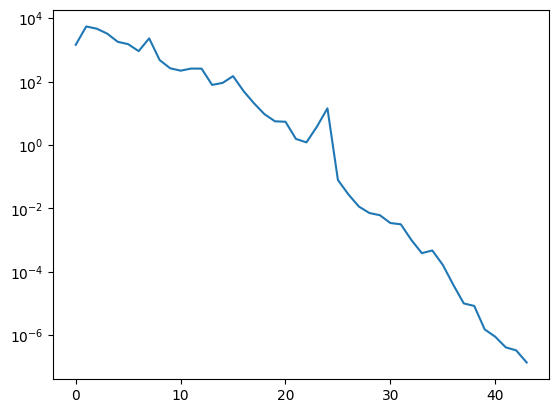

In [10]:
import os
import importlib

import sparse_solver

importlib.reload(sparse_solver)
from sparse_solver import SparseSolverWrapper

np.random.seed(42)
residuals = []
args = {'accel': 'bicgstab', 'tol': 1e-10, 'residuals': residuals}
solver = SparseSolverWrapper(Nx, Ny, dx, dy, backend="pyamg", solver_args=args)
solver.set_bottom_boundary_condition("dirichlet ")
solver.set_top_boundary_condition("dirichlet")
solver.set_left_boundary_condition("dirichlet")
solver.set_right_boundary_condition("dirichlet")
solver.create_sparse_matrix()

solver.solver = pyamg.smoothed_aggregation_solver(solver.A)   

rhs = np.random.rand(Nx, Ny)
rhs = rhs.astype(np.float32)
# rhs = np.zeros((Nx, Ny), 
#                dtype=np.float32)
rho = 100
g = 1
atm_pressure = 10000
atm_pressure_t = np.ones((Nx, Ny)) 
atm_pressure_t = atm_pressure_t * rho * dx * g
atm_pressure_t = np.cumsum(atm_pressure_t, axis=1)
atm_pressure_t = atm_pressure_t[:, ::-1]

rhs[:, 0] = atm_pressure_t[:, 0]
rhs[:, -1] = atm_pressure_t[:, -1]

rhs[0, :] = atm_pressure_t[0, :] 
rhs[-1, :] = atm_pressure_t[-1, :]

# rhs = rhs - np.mean(rhs)

solver.set_rhs(rhs)
solver.solve()
solution = solver.get_solution()
# print(solution[:, -1])
# print(solution[:, solution.shape[1] // 2])
# print(solution[:, 0])

print(f"rhs[:, 0] {np.mean(rhs[:, 0])} np.mean(solution[:, 0]): {np.mean(solution[:, 0])}")
print(f"rhs[:, -1] {np.mean(rhs[:, -1])} np.mean(solution[:, -1]): {np.mean(solution[:, -1])}")

print(f"rhs[0, :] {np.mean(rhs[0, :])} np.mean(solution[0, :]): {np.mean(solution[0, :])}")
print(f"rhs[-1, :] {np.mean(rhs[-1, :])} np.mean(solution[-1, :]): {np.mean(solution[-1, :])}")

print(f"mean bot derivative: {np.mean(solution[:, 0] - solution[:, 1]) / dx}")
print(f"mean top derivative: {np.mean(solution[:, -1] - solution[:, -2]) / dx}")
print(f"mean left derivative: {np.mean(solution[0, :] - solution[1, :]) / dy}")
print(f"mean right derivative: {np.mean(solution[-1, :] - solution[-2, :]) / dy}")

from matplotlib import pyplot as plt
plt.plot(residuals)
plt.yscale('log')
plt.show()

In [13]:
print(atm_pressure_t[0, :])
print(atm_pressure_t[-1, :])
print(atm_pressure_t[:, 0])
print(atm_pressure_t[:, -1])


[100.       99.21875  98.4375   97.65625  96.875    96.09375  95.3125
  94.53125  93.75     92.96875  92.1875   91.40625  90.625    89.84375
  89.0625   88.28125  87.5      86.71875  85.9375   85.15625  84.375
  83.59375  82.8125   82.03125  81.25     80.46875  79.6875   78.90625
  78.125    77.34375  76.5625   75.78125  75.       74.21875  73.4375
  72.65625  71.875    71.09375  70.3125   69.53125  68.75     67.96875
  67.1875   66.40625  65.625    64.84375  64.0625   63.28125  62.5
  61.71875  60.9375   60.15625  59.375    58.59375  57.8125   57.03125
  56.25     55.46875  54.6875   53.90625  53.125    52.34375  51.5625
  50.78125  50.       49.21875  48.4375   47.65625  46.875    46.09375
  45.3125   44.53125  43.75     42.96875  42.1875   41.40625  40.625
  39.84375  39.0625   38.28125  37.5      36.71875  35.9375   35.15625
  34.375    33.59375  32.8125   32.03125  31.25     30.46875  29.6875
  28.90625  28.125    27.34375  26.5625   25.78125  25.       24.21875
  23.4375   22.656

In [11]:
from jax_utils import jax_build_2d_laplacian_matrix_with_variable_steps

A = jax_build_2d_laplacian_matrix_with_variable_steps(Nx, Ny, dx, dy)
A.todense()

matrix([[-17.,  18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9., -17.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,  18., -17.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9.,   0.,   0., -36.,  18.,   0.,   9.,   0.,   0.],
        [  0.,   9.,   0.,   9., -36.,   9.,   0.,   9.,   0.],
        [  0.,   0.,   9.,   0.,  18., -36.,   0.,   0.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0., -17.,  18.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   9., -17.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  18., -17.]])

In [12]:
solver.A.todense()

matrix([[-17.,   9.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9., -17.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   9., -17.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -18.,   9.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   9., -18.,   9.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   9., -18.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   9.,   0.,   0., -17.,   9.,   0.],
        [  0.,   0.,   0.,   0.,   9.,   0.,   9., -17.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   9.,   0.,   9., -17.]],
       dtype=float32)

In [16]:
from scipy.sparse import diags
main_diag_x = -2 * np.ones(Nx) / (dx**2)
off_diag_x = np.ones(Nx - 1) / (dx**2)
Tx = diags([off_diag_x, main_diag_x, off_diag_x], [-1, 0, 1],
            shape=(Nx, Nx))
Tx.todense()
    

matrix([[-18.,   9.,   0.],
        [  9., -18.,   9.],
        [  0.,   9., -18.]])

In [18]:
np.array(solver.create_diag(Nx, dx))

array([[-18.,   9.,   0.],
       [  9., -18.,   9.],
       [  0.,   9., -18.]], dtype=float32)

In [21]:
Tx = Tx.tolil()
Tx[0, 1] = 2 / (dx**2)  # Left boundary mirror
Tx[-1, -2] = 2 / (dx**2)  # Right boundary mirror
Tx = Tx.tocsr()
Tx.todense()

matrix([[-18.,  18.,   0.],
        [  9., -18.,   9.],
        [  0.,  18., -18.]])

In [24]:
Tx_solver = solver.create_diag(Nx, dx)
Tx_solver = Tx_solver.at[0, 1].set(2 / (dx**2))
Tx_solver = Tx_solver.at[-1, -2].set(2 / (dx**2))
Tx_solver

Array([[-18.,  18.,   0.],
       [  9., -18.,   9.],
       [  0.,  18., -18.]], dtype=float32)

In [25]:
import jax.numpy as jnp

Ix_jax = jnp.identity(Nx)
Ix_jax

Array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

In [27]:
from scipy.sparse import kron, identity

Ix_scipy = identity(Nx)
Ix_scipy.todense()

matrix([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [30]:
kron(Ix_scipy, Tx).todense()

matrix([[-18.,  18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9., -18.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,  18., -18.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -18.,  18.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   9., -18.,   9.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  18., -18.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0., -18.,  18.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   9., -18.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  18., -18.]])

In [31]:
kron(Ix_scipy, Tx_solver).todense()

matrix([[-18.,  18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9., -18.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,  18., -18.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0., -18.,  18.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   9., -18.,   9.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,  18., -18.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0., -18.,  18.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   9., -18.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  18., -18.]])

In [57]:
Tx_jax = solver.create_diag(Nx, dx)
Ty_jax = solver.create_diag(Ny, dy)

bottom_boundary_condition = 'dirichlet'
top_boundary_condition = 'dirichlet'
left_boundary_condition = 'neumann'
right_boundary_condition = 'neumann'

if bottom_boundary_condition == 'dirichlet':
    Ty_jax = Ty_jax.at[0, :].set(0.0)
    Ty_jax = Ty_jax.at[0, 0].set(1.0)
elif bottom_boundary_condition == 'neumann':
    Ty_jax = Ty_jax.at[0, 1].set(2 / (dy**2))

if top_boundary_condition == 'dirichlet':
    Ty_jax = Ty_jax.at[-1, :].set(0.0)
    Ty_jax = Ty_jax.at[-1, -1].set(1.0)
elif top_boundary_condition == 'neumann':
    Ty_jax = Ty_jax.at[-1, -2].set(2 / (dy**2))

if left_boundary_condition == 'dirichlet':
    Tx_jax = Tx_jax.at[0, :].set(0.0)
    Tx_jax = Tx_jax.at[0, 0].set(1.0)
elif left_boundary_condition == 'neumann':
    Tx_jax = Tx_jax.at[0, 1].set(2 / (dx**2))

if right_boundary_condition == 'dirichlet':
    Tx_jax = Tx_jax.at[-1, :].set(0.0)
    Tx_jax = Tx_jax.at[-1, -1].set(1.0)
elif right_boundary_condition == 'neumann':
    Tx_jax = Tx_jax.at[-1, -2].set(2 / (dx**2))
        
Ix_jax = jnp.identity(Nx)
Iy_jax = jnp.identity(Ny)

A_jax = jnp.kron(Iy_jax, Tx_jax) + jnp.kron(Ty_jax, Ix_jax)
A_jax

Array([[-17.,  18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  9., -17.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,  18., -17.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  9.,   0.,   0., -36.,  18.,   0.,   9.,   0.,   0.],
       [  0.,   9.,   0.,   9., -36.,   9.,   0.,   9.,   0.],
       [  0.,   0.,   9.,   0.,  18., -36.,   0.,   0.,   9.],
       [  0.,   0.,   0.,   0.,   0.,   0., -17.,  18.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   9., -17.,   9.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  18., -17.]],      dtype=float32)

In [58]:
main_diag_x = -2 * np.ones(Nx) / (dx**2)
off_diag_x = np.ones(Nx - 1) / (dx**2)
Tx_scipy = diags([off_diag_x, main_diag_x, off_diag_x], [-1, 0, 1], shape=(Nx, Nx))
    
    # 1D Laplacian for y-direction
main_diag_y = -2 * np.ones(Ny) / (dy**2)
off_diag_y = np.ones(Ny - 1) / (dy**2)
Ty_scipy = diags([off_diag_y, main_diag_y, off_diag_y], [-1, 0, 1], shape=(Ny, Ny))
    
    # Apply boundary conditions
Tx_scipy = Tx_scipy.tolil()
Tx_scipy[0, 1] = 2 / (dx**2)  # Left boundary mirror
Tx_scipy[-1, -2] = 2 / (dx**2)  # Right boundary mirror
Tx_scipy = Tx_scipy.tocsr()
        
Ty_scipy = Ty_scipy.tolil()
Ty_scipy[0, :] = 0.0
Ty_scipy[0, 0] = 1.0     # Dirichlet row at bottom
Ty_scipy[-1, :] = 0.0
Ty_scipy[-1, -1] = 1.0   # Dirichlet row at top
Ty_scipy = Ty_scipy.tocsr()
    
    # Create identity matrices
Ix_scipy = identity(Nx)
Iy_scipy = identity(Ny)
    
# Combine using Kronecker products to create 2D Laplacian
A_scipy = kron(Iy_scipy, Tx_scipy) + kron(Ty_scipy, Ix_scipy)
A_scipy.todense()
    

matrix([[-17.,  18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9., -17.,   9.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,  18., -17.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  9.,   0.,   0., -36.,  18.,   0.,   9.,   0.,   0.],
        [  0.,   9.,   0.,   9., -36.,   9.,   0.,   9.,   0.],
        [  0.,   0.,   9.,   0.,  18., -36.,   0.,   0.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0., -17.,  18.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   9., -17.,   9.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,  18., -17.]])

In [59]:
Tx_scipy.todense(), Ty_scipy.todense()

(matrix([[-18.,  18.,   0.],
         [  9., -18.,   9.],
         [  0.,  18., -18.]]),
 matrix([[  1.,   0.,   0.],
         [  9., -18.,   9.],
         [  0.,   0.,   1.]]))

In [60]:
np.array(Tx_jax), np.array(Ty_jax)

(array([[-18.,  18.,   0.],
        [  9., -18.,   9.],
        [  0.,  18., -18.]], dtype=float32),
 array([[  1.,   0.,   0.],
        [  9., -18.,   9.],
        [  0.,   0.,   1.]], dtype=float32))